In [2]:
#!pip install ternary-diagram


In [2]:
!pip install mpltern

In [3]:
import mpltern as tern
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
modal_comp = pd.read_csv('Modal_composition.csv')
carbonate_comp = pd.read_csv('carbonate_composition.csv')
carbonate_comp

,Sample,calcite,dolomite,gypsum,total percentage
0,80823A,0.000,99.33,0,99.330
1,71923A,95.670,0.00,0,95.670
2,71923B,8.000,91.00,0,99.000
3,83123A,0.667,98.67,0,99.337


### Non-Soluble Ternary

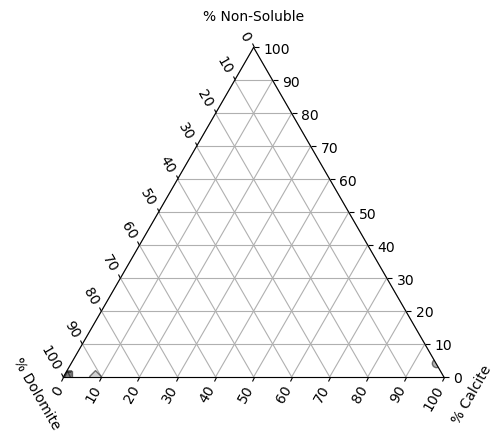

In [6]:
import numpy as np

import matplotlib.pyplot as plt
import mpltern

fig = plt.figure(figsize=(10.8, 4.8))
ax = fig.add_subplot(1, 2, 1, projection="ternary", zorder = 1)
ax.grid()

BMTC80823A = [(0.00667, .9933, 0.01)]
Omega71923A = [(.043, 0, .9567)]
Omega71923B = [(0.0033, 0.91, 0.08)]
Onon83123A = [(0.0067, .9867, 0.0067)]


# Unpack the points and plot them
ax.scatter(*zip(*BMTC80823A), color='Black', marker='s',  edgecolors= 'black', label='Bad Medicine - Tre Charros', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Omega71923A), color='dimgray', marker='o',  edgecolors= 'black', label='Omega Big Lime', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Omega71923B), color='darkgray', marker='D',  edgecolors= 'black', label='Omega Dolomite', alpha= 0.5, zorder = 2)
ax.scatter(*zip(*Onon83123A), color='gray', marker='^',  edgecolors= 'black', label='Onondaga', alpha= 0.5, zorder = 2)

ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
ax.taxis.set_ticks(ticks, labels=labels)
ax.laxis.set_ticks(ticks, labels=labels)
ax.raxis.set_ticks(ticks, labels=labels)

ax.set_tlabel('% Non-Soluble')
ax.set_rlabel('% Calcite')
ax.set_llabel('% Dolomite')

plt.savefig('non-soluble_ternary.png', dpi = 600)

plt.show()

### Non Soluble Spectrum

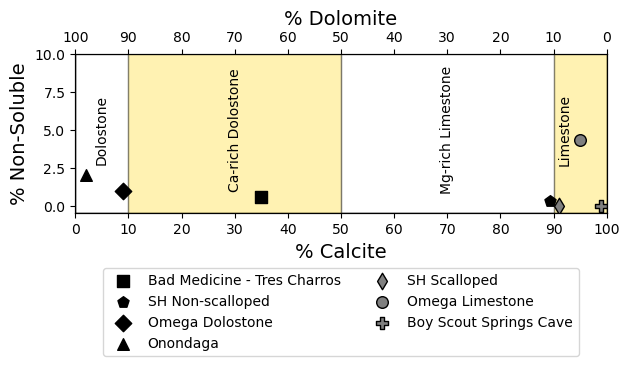

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

fig, ax = plt.subplots()
ax.set_ylim(-0.5, 10)
rectangle = plt.Rectangle((0, -0.5), 100, 100.5, edgecolor='black', facecolor='none')
ax.add_patch(rectangle)
ax_bottom = ax.twiny()
ax_bottom.set_xlim(100, 0)
ax_bottom.set_xticks(np.arange(100, -1, -10))
ax.set_xticks(np.arange(0, 101, 10))
ax.set_box_aspect(0.3)
ax_bottom.set_xlabel('% Dolomite', fontsize = 14)
ax.set_xlabel('% Calcite',  fontsize = 14)
ax.set_ylabel('% Non-Soluble',  fontsize = 14)

# Each x-value needs to be a dolomite concentration
BMTC80823A = (65, 0.6)
Omega71923A = ( 5, 4.3)
Omega71923B = (91, 1 )
Onon83123A = (98, 2)
LPSC = (9, 0.0) 
LPNS = (10.667, 0.3)
BSS90423 = (1, 0)


# Non-scalloped: Black 
# Scalloped: Gray

markersize = 70

ax_bottom.scatter(*BMTC80823A, color='black', marker= 's', edgecolors= 'black', linewidth = 1,  label='Bad Medicine - Tres Charros', s = markersize)

ax_bottom.scatter(*LPNS, color = 'black', marker= 'p', edgecolors= 'Black', linewidths= 1, label = 'SH Non-scalloped', s = markersize)


ax_bottom.scatter(*Omega71923B, color='black', marker = 'D', edgecolors= 'black', linewidth = 1, label='Omega Dolostone',   s= markersize)

ax_bottom.scatter(*Onon83123A, color='black', marker = '^', edgecolors= 'black', linewidth = 1, label='Onondaga',  s = markersize)

ax_bottom.scatter(*LPSC, color = 'gray', marker= 'd', edgecolors= 'Black', linewidths= 1, label = 'SH Scalloped', s = markersize)

ax_bottom.scatter(*Omega71923A, color='gray', marker= 'o', edgecolors= 'black', linewidth = 1, label='Omega Limestone' , s = markersize)

ax_bottom.scatter(*BSS90423, color = 'gray', marker = 'P', edgecolors= 'black', linewidths= 1, label = 'Boy Scout Springs Cave', s = markersize)


# filled Region
shade = 'gold'
Dolostone = patches.Rectangle((0, -0.5), 10, 10.5, edgecolor='black', facecolor='none', alpha=0.3)
Ca_rich_Dolostone = patches.Rectangle((10,-0.5), 40, 10.5, edgecolor='black', facecolor=shade, alpha=0.3 )
Mg_rich_Limestone = patches.Rectangle((50,-0.5),40, 10.5, edgecolor='black', facecolor='none', alpha=0.3)
Limestone = patches.Rectangle((90,-0.5),10, 10.5, edgecolor='black', facecolor=shade, alpha=0.3)
ax.add_patch(Dolostone)
ax.add_patch(Ca_rich_Dolostone)
ax.add_patch(Mg_rich_Limestone)
ax.add_patch(Limestone)

# Classification Labels

ax.text(5, 5, 'Dolostone', rotation = 90, va = 'center', ha = 'center')
ax.text(30, 5, 'Ca-rich Dolostone', rotation = 90, va = 'center', ha = 'center')
ax.text(70, 5, 'Mg-rich Limestone', rotation = 90, va = 'center', ha = 'center')
ax.text(92, 5, 'Limestone', rotation = 90, va = 'center', ha = 'center')

# Show the plot
plt.legend(loc = 'upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()

plt.savefig('dolomite-calcite-spectrum-for-gsa.png', dpi = 600)
plt.show()
 

### Carbonate Ternary Diagram

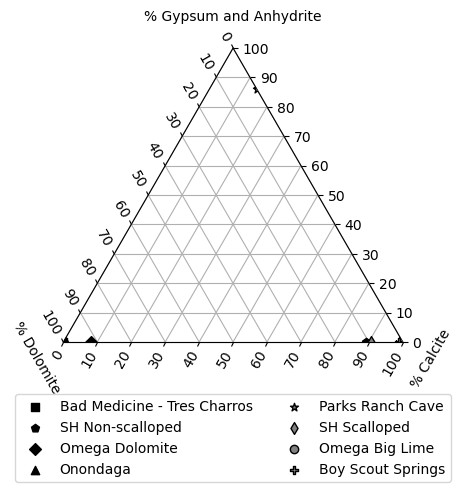

In [8]:
import numpy as np

import matplotlib.pyplot as plt
import mpltern

fig = plt.figure(figsize=(10.8, 4.8))
ax = fig.add_subplot(1, 2, 1, projection="ternary", zorder = 1)
ax.grid()

# Calcite, Dolomite, Gypsum, actual: Gypsum, dolomite, calcite
BMTC80823A = [(0, 100, 0 )]
Omega71923A = [(0, 0, 100)]
Omega71923B = [(0, 91.95, 8.05)]
Onon83123A = [(0 , 99.33, 0.67)]
PRC111123A = [(85.57,0, 14.03)]
LPSC = [(0, 9.333, 90.667)]
LPNS = [(0, 10.7, 89.3 )]
BSS = [(0, 1, 99)]

# Unpack the points and plot them
ax.scatter(*zip(*BMTC80823A), color='black', marker='s',  edgecolors= 'black', label='Bad Medicine - Tres Charros', zorder = 4)
ax.scatter(*zip(*LPNS), color = 'black', marker = 'p', edgecolors= 'black', label = 'SH Non-scalloped', zorder = 4)
ax.scatter(*zip(*Omega71923B), color='black', marker='D',  edgecolors= 'black', label='Omega Dolomite', zorder =4)
ax.scatter(*zip(*Onon83123A), color='black', marker='^',  edgecolors= 'black', label='Onondaga', zorder = 4)
ax.scatter(*zip(*PRC111123A), color = 'gray', marker = '*', edgecolors= 'black', label = 'Parks Ranch Cave', zorder = 4)
ax.scatter(*zip(*LPSC), color = 'gray', marker = 'd', edgecolors= 'black', label = 'SH Scalloped', zorder = 4)
ax.scatter(*zip(*Omega71923A), color='gray', marker='o',  edgecolors= 'black', label='Omega Big Lime', zorder = 4)
ax.scatter(*zip(*BSS), color = 'gray', marker = 'P',  edgecolors= 'black', label='Boy Scout Springs', zorder = 4 )


ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
ax.taxis.set_ticks(ticks, labels=labels)
ax.laxis.set_ticks(ticks, labels=labels)
ax.raxis.set_ticks(ticks, labels=labels)

ax.set_tlabel('% Gypsum and Anhydrite')
ax.set_rlabel('% Calcite')
ax.set_llabel('% Dolomite')

plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.5), ncol = 2)
plt.tight_layout()
plt.savefig('ternary_modal_plot.png', bbox_inches = 'tight', dpi = 600)

plt.show()

In [9]:
import ternary
scale = 100

figure, tax = ternary.figure(scale=scale)
figure.set_size_inches(5, 5)

# Draw Boundary and Gridlines
tax.boundary(linewidth=1.5)

tax.gridlines(color="black", multiple=10, linewidth=0.5)

# Set Axis labels and Title
fontsize = 14
offset = 0.14
tax.left_axis_label("% Dolomite", fontsize=12, offset=offset)
tax.right_axis_label("% Gypsum and Anhydrite", fontsize=12, offset=offset)
tax.bottom_axis_label("% Calcite", fontsize=12, offset=offset)
tax.right_corner_label("Limestone", rotation= 45, fontsize=fontsize, offset = 0.2)
tax.top_corner_label("Gypsum", fontsize=fontsize, offset = .2)
tax.left_corner_label("Dolostone", rotation= -45, fontsize=fontsize, offset = 0.2)

BMTC80823A = (0, 100, 0)
Omega71923A = (0, 0, 100)
Omega71923B = (0, 91.95, 8.05)
Onon83123A = (0 , 99.33, 0.67)
PRC111123A = (85.57,0, 14.03)
LPSC = (0, 9.333, 90.667)
LPNS = (0, 10.7, 89.3 )
BSS = (0, 1, 99)

p1 = (22, 8, 10)
p2 = (0, 22, 16)
tax.line(p1, p2, linewidth=1, marker='s', color='green', linestyle=":")

tax.plot(BMTC80823A, color='black', marker='s',  edgecolors= 'black', label='Bad Medicine - Tres Charros')
tax.scatter(LPNS, color = 'black', marker = 'p', edgecolors= 'black', label = 'SH Non-scalloped')
tax.scatter(Omega71923B, color='black', marker='D',  edgecolors= 'black', label='Omega Dolomite')
tax.scatter(Onon83123A, color='black', marker='^',  edgecolors= 'black', label='Onondaga')
tax.scatter(PRC111123A, color = 'gray', marker = '*', edgecolors= 'black', label = 'Parks Ranch Cave')
tax.scatter(LPSC, color = 'gray', marker = 'd', edgecolors= 'black', label = 'SH Scalloped')
tax.scatter(Omega71923A, color='gray', marker='o',  edgecolors= 'black', label='Omega Big Lime')
tax.scatter(BSS, color = 'gray', marker = 'P',  edgecolors= 'black', label='Boy Scout Springs')

# Set ticks
tax.ticks(axis='lbr', linewidth=1, offset=0.02, multiple= 10)

# Background color
tax.set_background_color(color="whitesmoke", alpha=0.7) # the detault, essentially

# Remove default Matplotlib Axes
tax.clear_matplotlib_ticks()
tax.get_axes().axis('off')

ternary.plt.show()


ModuleNotFoundError: No module named 'ternary'

solubility calculation


In [12]:
def solubility(gypsum, calcite, dolomite, total):

    solu = (gypsum + calcite + dolomite)/(total) *100
    return solu

In [14]:
final_counts = pd.read_csv('final_modal_counts.csv')
final_counts

,sample,calcite,dolomite,gypsum,silica,clay,other
0,80823A,0.0,298.0,0.0,0.0,0.0,2.0
1,71923A,287.0,0.0,0.0,0.0,0.0,13.0
2,71923B,24.0,274.0,0.0,0.0,0.0,2.0
3,83123A,2.0,296.0,0.0,0.0,0.0,2.0
4,PRC,42.0,0.0,249.0,0.0,0.0,9.0
5,LPSC,272.0,28.0,0.0,0.0,0.0,0.0
6,LPNS,267.0,32.0,0.0,0.0,0.0,1.0
7,90423A,297.0,3.0,0.0,0.0,0.0,0.0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
final_counts['solubility'] = solubility(final_counts['gypsum'], final_counts['calcite'], final_counts['dolomite'], 300)

In [16]:
final_counts

,sample,calcite,dolomite,gypsum,silica,clay,other,solubility
0,80823A,0.0,298.0,0.0,0.0,0.0,2.0,99.333333
1,71923A,287.0,0.0,0.0,0.0,0.0,13.0,95.666667
2,71923B,24.0,274.0,0.0,0.0,0.0,2.0,99.333333
3,83123A,2.0,296.0,0.0,0.0,0.0,2.0,99.333333
4,PRC,42.0,0.0,249.0,0.0,0.0,9.0,97.000000
5,LPSC,272.0,28.0,0.0,0.0,0.0,0.0,100.000000
6,LPNS,267.0,32.0,0.0,0.0,0.0,1.0,99.666667
7,90423A,297.0,3.0,0.0,0.0,0.0,0.0,100.000000
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
